In [245]:
import kagglehub
import os
import pandas as pd


In [246]:

# # Download latest version
# path = kagglehub.dataset_download("kathir1k/youtube-influencers-data")

# print(os.path.join(path, os.listdir(path)[0]))


In [247]:
import chardet

with open(os.path.join(path, os.listdir(path)[0]), "rb") as f:
    result = chardet.detect(f.read(10000))

print(result['encoding'])



Windows-1252


In [248]:
df = pd.read_csv(os.path.join(path, os.listdir(path)[0]), encoding=result['encoding'])
df[["Video Link", "Channel URL", "Date of Video Upload", "Creator Name"]]

,Video Link,Channel URL,Date of Video Upload,Creator Name
0,https://www.youtube.com/watch?v=_0fUOJ55gis,https://www.youtube.com/c/sriharick,7/29/2022,srihari ck
1,https://www.youtube.com/watch?v=_70MSLPRfZI,https://www.youtube.com/c/ChaibisketTelugu,5/22/2022,Chai Bisket
2,https://www.youtube.com/watch?v=_8gfCdt3H00&t=87s,https://www.youtube.com/channel/UCcIUnCsBfONvb...,2/9/2021,Virda Warsi
3,https://www.youtube.com/watch?v=_CkFNJgKsFs,https://www.youtube.com/c/trtworld,9/13/2022,TRT
4,https://www.youtube.com/watch?v=_GFkHA5EZdE,Vogue - YouTube,3/21/2017,Vogue
...,...,...,...,...
900,https://www.youtube.com/watch?v=GS18WawA-t0,https://www.youtube.com/c/SahilOnlineTVnews,9/29/2022,Sahil Online TV News
901,https://www.youtube.com/watch?v=_tc_APkjH2Q,https://www.youtube.com/sahilonline,8/6/2017,Sahil Online TV News
902,https://www.youtube.com/watch?v=Xfj4osSYfhU,https://www.youtube.com/sahilonline,1/3/2021,Sahil Online Bhatkal
903,https://www.youtube.com/watch?v=mGEHqwVz0eI,https://www.youtube.com/sahilonline,3/6/2022,Sahil Online Bhatkal


## Data Manupilation

In [249]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 905 entries, 0 to 904
Data columns (total 24 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   Video Link                             905 non-null    object 
 1   Video Views                            905 non-null    object 
 2   Video Title                            905 non-null    object 
 3   Channel URL                            905 non-null    object 
 4   Creator Name                           894 non-null    object 
 5   Creator Gender                         591 non-null    object 
 6   Total Channel Subcribers               905 non-null    object 
 7   Total Chanel Views                     905 non-null    object 
 8   Duration of Video                      905 non-null    object 
 9   Duration in Seconds                    905 non-null    object 
 10  Date of Video Upload                   905 non-null    object 
 11  No of 

In [250]:
df.drop(columns=['Video Link','Intern Who Collected the Data'], inplace=True)

### String to Numeric

In [251]:
df[["Video Views","Total Channel Subcribers","Total Chanel Views","Duration in Seconds","No of Comments"]]

,Video Views,Total Channel Subcribers,Total Chanel Views,Duration in Seconds,No of Comments
0,"146,059",40200,7964284,"1,841.00",419
1,"231,969",920000,137535681,864.00,189
2,878,458,72945,492.00,0
3,"9,965",1680000,541653219,66.00,77
4,"39,780,561",12100000,3600496171,460.00,28221
...,...,...,...,...,...
900,"6,892",594000,129926690,827.00,15
901,"16,554",594000,129926690,404.00,0
902,"32,798",23500,5104872,384.00,0
903,"1,503",23500,5104872,279.00,0


In [252]:

df['Video Views'] = df['Video Views'].str.replace(',', '')
df['Video Views'] = pd.to_numeric(df['Video Views'], errors='coerce')


df['Total Channel Subcribers'] = df['Total Channel Subcribers'].str.replace(',', '')
df['Total Channel Subcribers'] = pd.to_numeric(df['Total Channel Subcribers'], errors='coerce')


df['Total Chanel Views'] = df['Total Chanel Views'].str.replace(',', '')
df['Total Chanel Views'] = pd.to_numeric(df['Total Chanel Views'], errors='coerce')


df['Duration in Seconds'] = df['Duration in Seconds'].str.replace(',', '')
df['Duration in Seconds'] = pd.to_numeric(df['Duration in Seconds'], errors='coerce')

df['No of Comments'] = df['No of Comments'].str.replace(',', '')
df['No of Comments'] = pd.to_numeric(df['No of Comments'], errors='coerce')



In [253]:
df['Premiered or Not'] = df['Premiered or Not'].str.strip().str.lower().map({'yes': 1, 'no': 0})

In [254]:
df.describe()

,Video Views,Total Channel Subcribers,Total Chanel Views,Duration in Seconds,No of Likes,Hashtags,No of Comments,Maximum Quality of the Video,No of Videos the Channel,No of Playlist,Premiered or Not,Community Engagement (Posts per week)
count,9.050000e+02,9.030000e+02,8.960000e+02,905.000000,9.040000e+02,905.000000,9.050000e+02,905.000000,905.000000,896.000000,905.000000,905.000000
mean,5.447910e+07,1.043915e+07,2.235640e+09,1927.761326,5.840101e+05,1.030939,4.558636e+04,1227.712707,4962.866298,82.246652,0.111602,4.516022
std,4.002179e+08,2.410166e+07,1.055352e+10,6395.720819,2.959309e+06,1.835350,4.786907e+05,419.254719,24193.140397,446.041267,0.315051,19.377195
min,2.300000e+01,3.400000e+01,3.600000e+01,0.000000,0.000000e+00,0.000000,0.000000e+00,240.000000,1.000000,0.000000,0.000000,0.000000
25%,2.013700e+05,3.270000e+05,3.599062e+07,314.000000,5.475000e+03,0.000000,2.280000e+02,1080.000000,150.000000,6.000000,0.000000,0.000000
50%,1.293867e+06,2.100000e+06,2.475236e+08,645.000000,3.250000e+04,0.000000,1.221000e+03,1080.000000,389.000000,16.000000,0.000000,1.000000
75%,9.002909e+06,9.300000e+06,1.267778e+09,1034.000000,1.845000e+05,2.000000,7.016000e+03,1080.000000,1393.000000,47.250000,0.000000,3.000000
max,7.990990e+09,3.052000e+08,2.022970e+11,62700.000000,4.900000e+07,28.000000,1.124480e+07,2160.000000,420000.000000,6000.000000,1.000000,341.000000


### Missing Names

In [255]:
null_names = df[df["Creator Name"].isnull()][["Creator Name","Channel URL"]].copy()

In [256]:
null_names["Creator Name"] = null_names["Channel URL"].apply(lambda x: x.split("/")[-1])
null_names

,Creator Name,Channel URL
88,batmanarkham,https://www.youtube.com/c/batmanarkham
91,cokestudio,https://www.youtube.com/c/cokestudio
101,TrendMaxTV,https://www.youtube.com/c/TrendMaxTV
183,NDTV,https://www.youtube.com/c/NDTV
239,Ashstudio7HD,https://www.youtube.com/c/Ashstudio7HD
275,guardian,https://www.youtube.com/guardian
293,GQ,https://www.youtube.com/c/GQ
322,IMAGINEDRAGONSLIVEE,https://www.youtube.com/c/IMAGINEDRAGONSLIVEE
340,variant,https://www.youtube.com/variant
352,GreatBigStory,https://www.youtube.com/c/GreatBigStory


In [257]:
df.loc[df["Creator Name"].isnull(), "Creator Name"] = null_names["Creator Name"]

### Standardizing the Date Format

In [258]:
df["Date of Video Upload"] = df["Date of Video Upload"].str.replace("-", "/", regex=False)

In [259]:
# 1. Boşlukları ve görünmeyen karakterleri temizle
df["Date of Video Upload"] = df["Date of Video Upload"].astype(str).str.strip().str.replace(r"[^\x00-\x7F]+", "", regex=True)

# 2. Tarihleri tekrar çevir (gün/ay/yıl formatında olduğunu varsayarak)
df["Date of Video Upload"] = pd.to_datetime(df["Date of Video Upload"], dayfirst=True,format='mixed')




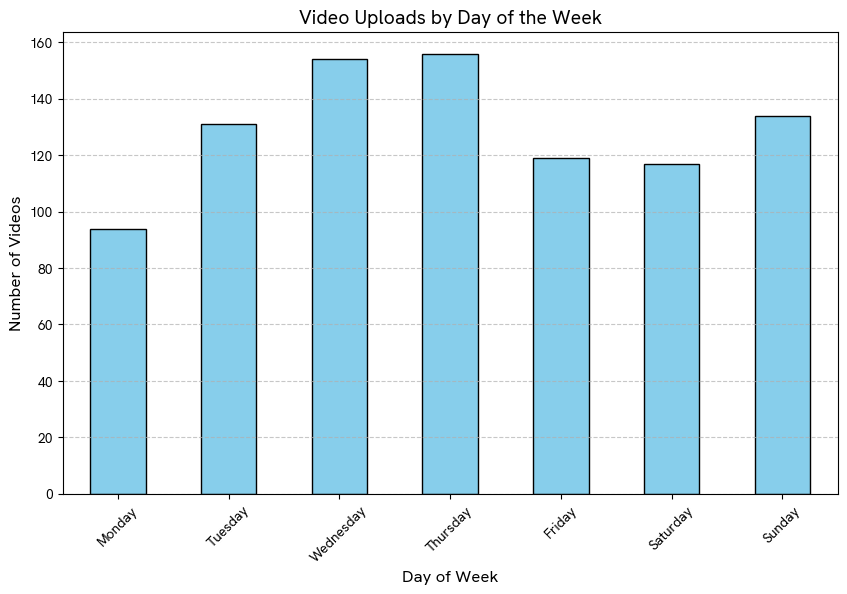

In [260]:
import matplotlib.pyplot as plt

# Tarihi datetime yap
df["Date of Video Upload"] = pd.to_datetime(df["Date of Video Upload"])

# Hafta günü çıkar (0=Monday, 6=Sunday)
df["DayOfWeek"] = df["Date of Video Upload"].dt.day_name()

# Sayım
day_counts = df["DayOfWeek"].value_counts().reindex(
    ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
)

# Görselleştirme
plt.figure(figsize=(10,6))
day_counts.plot(kind="bar", color="skyblue", edgecolor="black")

plt.title("Video Uploads by Day of the Week", fontsize=14)
plt.xlabel("Day of Week", fontsize=12)
plt.ylabel("Number of Videos", fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()


In [261]:
day_dummies = pd.get_dummies(df["DayOfWeek"])
df = pd.concat([df, day_dummies], axis=1)
df[["Date of Video Upload","DayOfWeek","Friday","Monday","Saturday","Sunday","Thursday","Tuesday","Wednesday"]]

,Date of Video Upload,DayOfWeek,Friday,Monday,Saturday,Sunday,Thursday,Tuesday,Wednesday
0,2022-07-29,Friday,True,False,False,False,False,False,False
1,2022-05-22,Sunday,False,False,False,True,False,False,False
2,2021-09-02,Thursday,False,False,False,False,True,False,False
3,2022-09-13,Tuesday,False,False,False,False,False,True,False
4,2017-03-21,Tuesday,False,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...
900,2022-09-29,Thursday,False,False,False,False,True,False,False
901,2017-06-08,Thursday,False,False,False,False,True,False,False
902,2021-03-01,Monday,False,True,False,False,False,False,False
903,2022-06-03,Friday,True,False,False,False,False,False,False


In [262]:
print(type(df["Date of Video Upload"][0]))


<class 'pandas._libs.tslibs.timestamps.Timestamp'>


In [263]:
df.sort_values("Date of Video Upload")["Date of Video Upload"]

866   2005-04-24
867   2006-10-10
446   2007-10-28
868   2008-09-22
21    2009-07-18
         ...    
434   2022-12-09
111   2022-12-09
417   2022-12-09
493   2022-12-09
514   2022-12-09
Name: Date of Video Upload, Length: 905, dtype: datetime64[ns]

In [264]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 905 entries, 0 to 904
Data columns (total 30 columns):
 #   Column                                 Non-Null Count  Dtype         
---  ------                                 --------------  -----         
 0   Video Views                            905 non-null    int64         
 1   Video Title                            905 non-null    object        
 2   Channel URL                            905 non-null    object        
 3   Creator Name                           905 non-null    object        
 4   Creator Gender                         591 non-null    object        
 5   Total Channel Subcribers               903 non-null    float64       
 6   Total Chanel Views                     896 non-null    float64       
 7   Duration of Video                      905 non-null    object        
 8   Duration in Seconds                    905 non-null    float64       
 9   Date of Video Upload                   905 non-null    datetime64

## EDA

In [265]:
import matplotlib.pyplot as plt
from matplotlib import rcParams, font_manager as fm

font_path = "/Users/emirysaglam/Library/Fonts/HankenGrotesk-VariableFont_wght.ttf"
fm.fontManager.addfont(font_path)
font_name = fm.FontProperties(fname=font_path).get_name()

rcParams['font.family'] = font_name

### Log Transform

In [266]:
import numpy as np

numerical_columns = df.select_dtypes(include=['number']).columns.tolist()

log_numeric_columns = []

for col in numerical_columns:
    df[f'Log {col}'] = np.log(df[col].replace(0, np.nan))
    log_numeric_columns.append(f'Log {col}')

df[log_numeric_columns].head()

,Log Video Views,Log Total Channel Subcribers,Log Total Chanel Views,Log Duration in Seconds,Log No of Likes,Log Hashtags,Log No of Comments,Log Maximum Quality of the Video,Log No of Videos the Channel,Log No of Playlist,Log Premiered or Not,Log Community Engagement (Posts per week)
0,11.891766,10.601622,15.890478,7.518064,8.809863,NaN,6.037871,6.984716,6.135565,2.484907,NaN,0.000000
1,12.354359,13.732129,18.739394,6.761573,8.961879,0.0,5.241747,6.984716,5.525453,2.484907,0.0,0.693147
2,6.777647,6.126869,11.197461,6.198479,6.754604,NaN,NaN,6.579251,5.062595,NaN,NaN,NaN
3,9.206834,14.334304,20.110137,4.189655,5.236442,NaN,4.343805,6.984716,10.747401,3.871201,NaN,2.995732
4,17.498889,16.308716,22.004337,6.131226,13.711261,NaN,10.247822,6.984716,7.962764,4.727388,NaN,0.000000


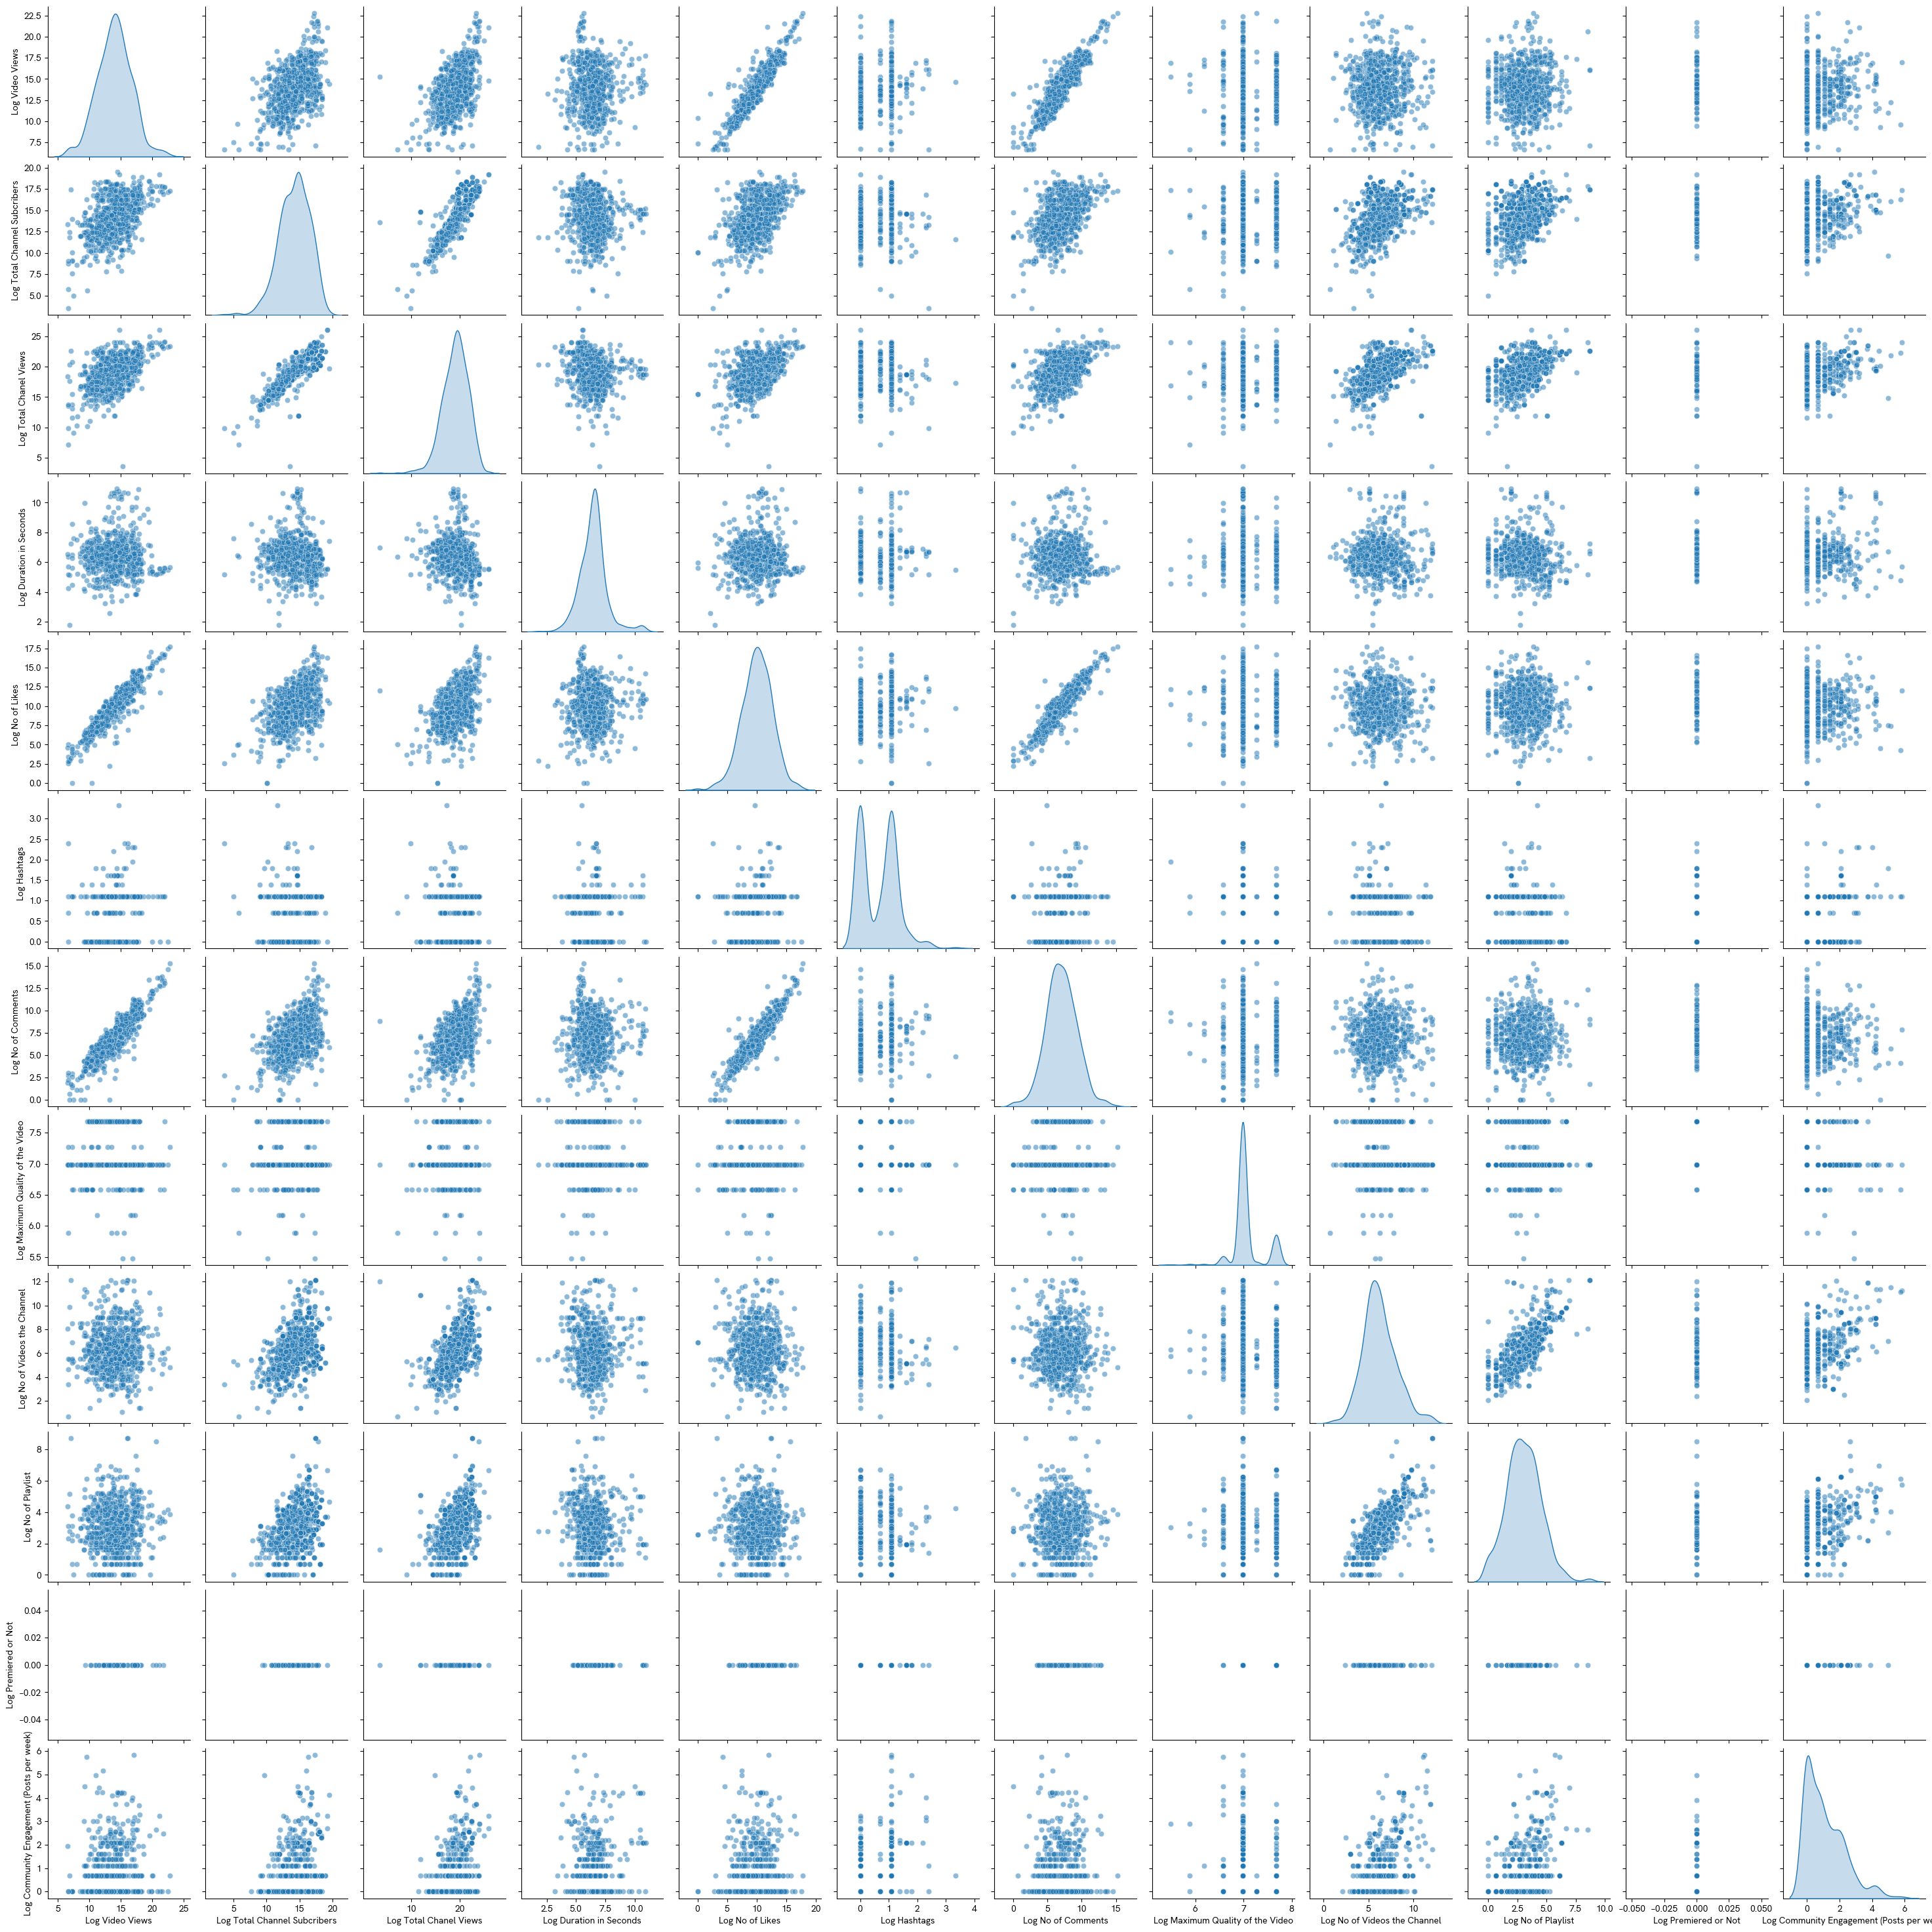

In [305]:
import seaborn as sns
sns.pairplot(df[log_numeric_columns], diag_kind='kde', markers='o', plot_kws={'alpha': 0.5})

<Axes: >

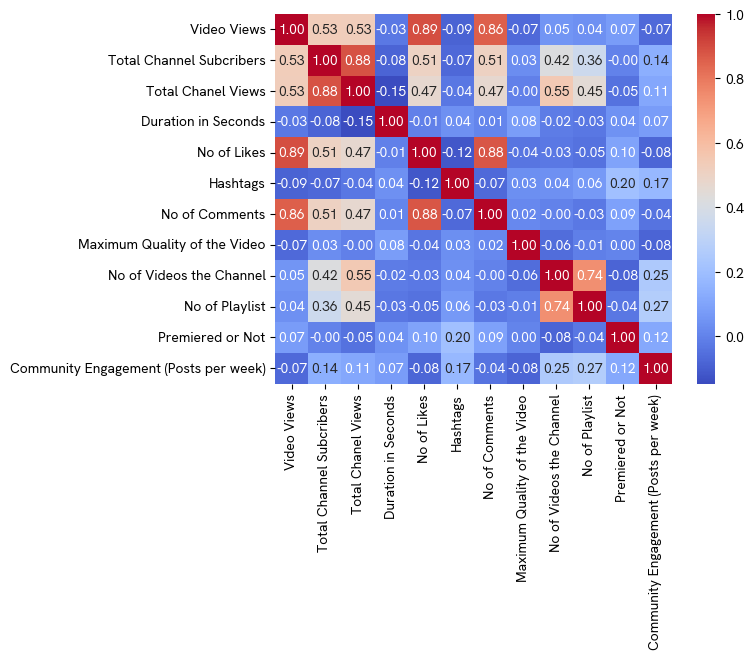

In [268]:
sns.heatmap(df[numerical_columns].corr("spearman"), annot=True, cmap='coolwarm', fmt='.2f')

### Marketing Cost Analysis

In [269]:
# İstenen aralık
a, b = 0, 8

# Grup ortalamalarını bul
group_means = df.groupby("Creator Name")["Log Video Views"].transform("mean")

# Min-Max Scaling
scaled_means = a + (group_means - group_means.min()) * (b - a) / (group_means.max() - group_means.min())

# Yeni sütun olarak ekle
df["CPM"] = scaled_means


In [270]:
# İstenen aralık
a, b = 0, 2

# Grup ortalamalarını bul
group_means = df.groupby("Creator Name")["Log Total Channel Subcribers"].transform("mean")

# Min-Max Scaling
scaled_means = a + (group_means - group_means.min()) * (b - a) / (group_means.max() - group_means.min())

# Yeni sütun olarak ekle
df["Sub Bonus"] = scaled_means


In [271]:
df["CPM_Enhanced"] = df["CPM"] + df["Sub Bonus"]
df["Marketing Cost"] = df["CPM_Enhanced"] * df["Video Views"]



### Bucketing by Log of Video Views

In [272]:
# First, we need to calculate our IQR.
q1 = df["Log Video Views"].quantile(0.25)                 
q3 = df["Log Video Views"].quantile(0.75)
iqr = q3 - q1

# Now let's calculate upper and lower bounds.
lower = q1 - 1.5*iqr
upper = q3 + 1.5*iqr

# Let us create our bins:
num_bins = 6
bin_width = (upper - lower) / num_bins
bins = [lower + i*bin_width for i in range(num_bins)]
bins += [upper, float('inf')]  # Now we add our last bin, which will contain any value greater than the upper-bound of the IQR.

# Let us create our labels:
labels = [f'Bucket {i}' for i in range(1,num_bins+1)]
labels.append('Outside IQR')

# Finally, we add a new column to the df:
df['Log Video Views Bucket'] = pd.cut(df["Log Video Views"], bins=bins, labels=labels)
df[["Log Video Views",'Log Video Views Bucket']]

,Log Video Views,Log Video Views Bucket
0,11.891766,Bucket 3
1,12.354359,Bucket 3
2,6.777647,Bucket 1
3,9.206834,Bucket 2
4,17.498889,Bucket 5
...,...,...
900,8.838117,Bucket 1
901,9.714383,Bucket 2
902,10.398123,Bucket 2
903,7.315218,Bucket 1


#### Removing Outliers for Each Bucket

In [273]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

numeric_cols = ['Video Views', 'Marketing Cost', 'No of Likes', 'No of Comments']

# Function to remove outliers by IQR for each group
def remove_outliers_iqr(df_group):
    for col in numeric_cols:
        Q1 = df_group[col].quantile(0.25)
        Q3 = df_group[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.8 * IQR
        upper_bound = Q3 + 1.8 * IQR
        
        df_group = df_group[(df_group[col] >= lower_bound) & (df_group[col] <= upper_bound)]
    return df_group

# Apply group-wise outlier removal
df = df.groupby("Log Video Views Bucket").apply(remove_outliers_iqr).reset_index(drop=True)



/var/folders/6j/1nsywzcs1v5_6gn_3972hssr0000gn/T/ipykernel_42097/1535045599.py:19: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df = df.groupby("Log Video Views Bucket").apply(remove_outliers_iqr).reset_index(drop=True)
/var/folders/6j/1nsywzcs1v5_6gn_3972hssr0000gn/T/ipykernel_42097/1535045599.py:19: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby("Log Video Views Bucket").apply(remove_outliers_iqr).reset_index(drop=True)


### Bucket Analysis

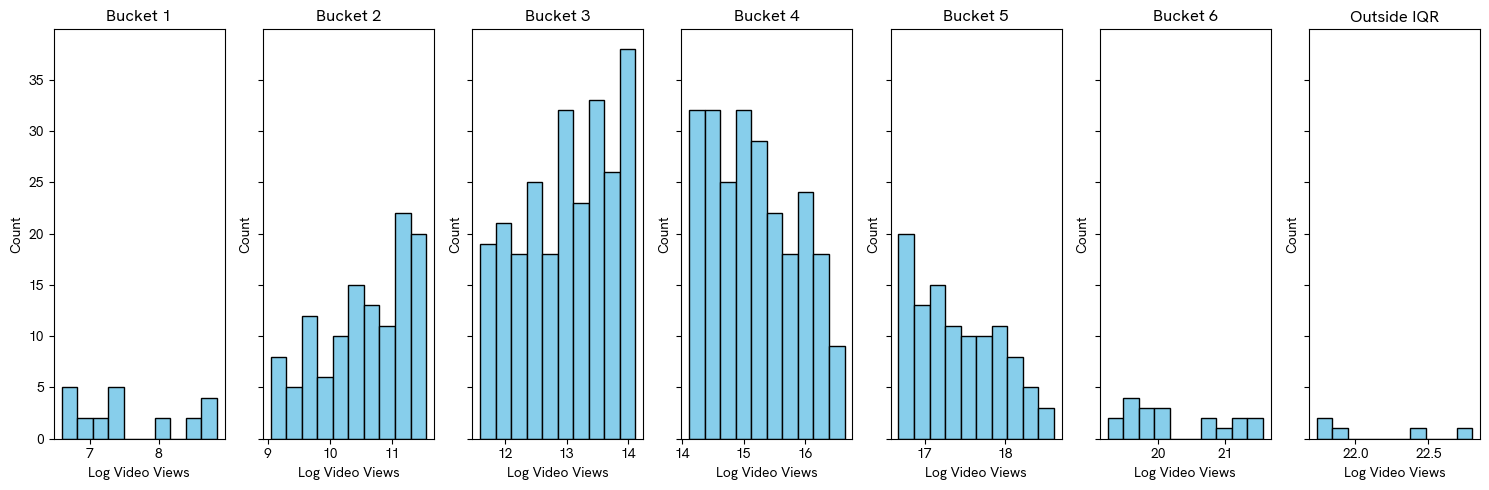

In [274]:
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, len(labels), figsize=(15, 5), sharey=True)
for i, label in enumerate(labels):
    ax = axes[i]
    subset = df[df['Log Video Views Bucket'] == label]['Log Video Views']
    ax.hist(subset, bins=10, color='skyblue', edgecolor='black')
    ax.set_title(label)
    ax.set_xlabel('Log Video Views')
    ax.set_ylabel('Count')

plt.tight_layout()
plt.show()


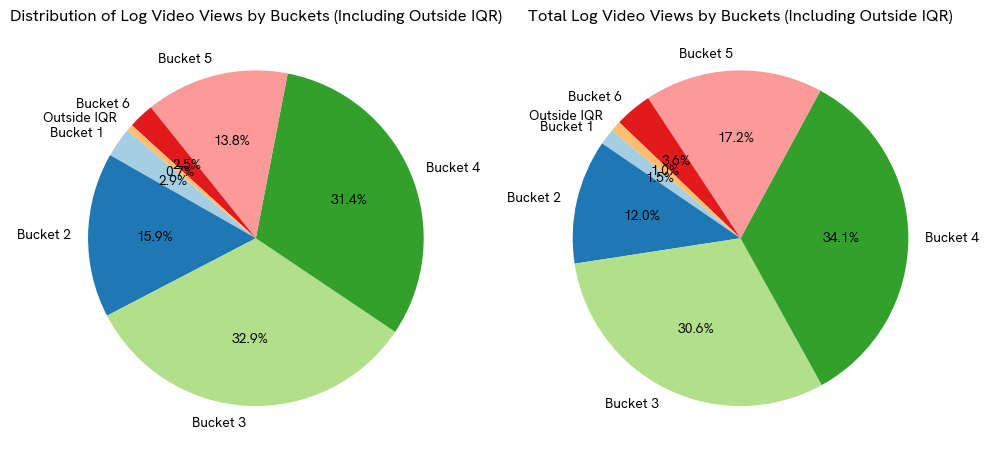

In [275]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

bucket_counts = df.groupby('Log Video Views Bucket',observed=True)['Log Video Views'].count().reindex(labels).copy()
bucket_sums = df.groupby('Log Video Views Bucket',observed=True)['Log Video Views'].sum().reindex(labels).copy()

# Pie chart for bucket counts
axes[0].pie(bucket_counts, labels=labels, autopct='%1.1f%%', startangle=140, colors=plt.cm.Paired.colors)
axes[0].set_title('Distribution of Log Video Views by Buckets (Including Outside IQR)')

# Pie chart for bucket sums
axes[1].pie(bucket_sums, labels=labels, autopct='%1.1f%%', startangle=140, colors=plt.cm.Paired.colors)
axes[1].set_title('Total Log Video Views by Buckets (Including Outside IQR)')

plt.tight_layout()
plt.show()

In [276]:
test_data = df[df["Log Video Views Bucket"] != "Outside IQR"].dropna(subset=["Log Video Views Bucket"]).copy()
test_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 763 entries, 0 to 762
Data columns (total 47 columns):
 #   Column                                     Non-Null Count  Dtype         
---  ------                                     --------------  -----         
 0   Video Views                                763 non-null    int64         
 1   Video Title                                763 non-null    object        
 2   Channel URL                                763 non-null    object        
 3   Creator Name                               763 non-null    object        
 4   Creator Gender                             473 non-null    object        
 5   Total Channel Subcribers                   762 non-null    float64       
 6   Total Chanel Views                         755 non-null    float64       
 7   Duration of Video                          763 non-null    object        
 8   Duration in Seconds                        763 non-null    float64       
 9   Date of Video Upload      

In [277]:
bucket_names = ['Bucket 1', 'Bucket 2', 'Bucket 3', 'Bucket 4', 'Bucket 5', 'Bucket 6']

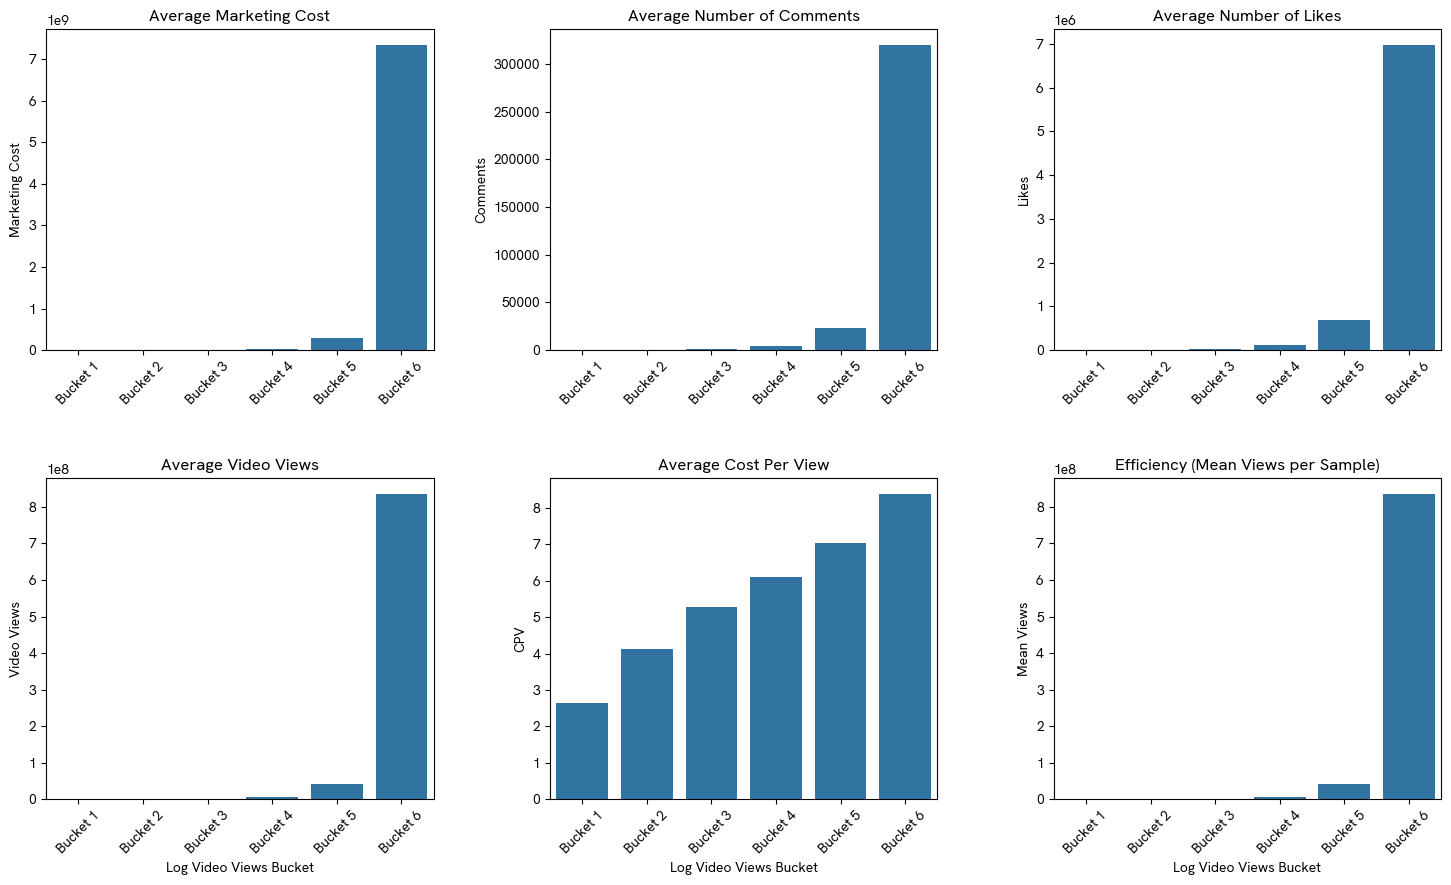

In [278]:
import matplotlib.pyplot as plt
import seaborn as sns

grouped = test_data.groupby("Log Video Views Bucket", observed=True)
bucket_names = grouped.size().index.astype(str)

# Prepare the CPV series again (if not already in test_data)
test_data['CPV'] = test_data['Marketing Cost'] / test_data['Video Views']
cpv_mean = grouped['CPV'].mean()

efficiency = grouped['Video Views'].mean()  # mean views per sample

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
plt.subplots_adjust(hspace=0.4, wspace=0.3)

# Plot 1: Average Marketing Cost
sns.barplot(x=bucket_names, y=grouped['Marketing Cost'].mean(), ax=axes[0,0])
axes[0,0].set_title("Average Marketing Cost")
axes[0,0].set_xlabel("")
axes[0,0].set_ylabel("Marketing Cost")
axes[0,0].tick_params(axis='x', rotation=45)

# Plot 2: Average No of Comments
sns.barplot(x=bucket_names, y=grouped['No of Comments'].mean(), ax=axes[0,1])
axes[0,1].set_title("Average Number of Comments")
axes[0,1].set_xlabel("")
axes[0,1].set_ylabel("Comments")
axes[0,1].tick_params(axis='x', rotation=45)

# Plot 3: Average No of Likes
sns.barplot(x=bucket_names, y=grouped['No of Likes'].mean(), ax=axes[0,2])
axes[0,2].set_title("Average Number of Likes")
axes[0,2].set_xlabel("")
axes[0,2].set_ylabel("Likes")
axes[0,2].tick_params(axis='x', rotation=45)

# Plot 4: Average Video Views
sns.barplot(x=bucket_names, y=grouped['Video Views'].mean(), ax=axes[1,0])
axes[1,0].set_title("Average Video Views")
axes[1,0].set_xlabel("Log Video Views Bucket")
axes[1,0].set_ylabel("Video Views")
axes[1,0].tick_params(axis='x', rotation=45)

# Plot 5: Average Cost Per View (CPV)
sns.barplot(x=cpv_mean.index.astype(str), y=cpv_mean.values, ax=axes[1,1])
axes[1,1].set_title("Average Cost Per View")
axes[1,1].set_xlabel("Log Video Views Bucket")
axes[1,1].set_ylabel("CPV")
axes[1,1].tick_params(axis='x', rotation=45)

# Plot 6: Efficiency (Mean Video Views per Sample)
sns.barplot(x=efficiency.index.astype(str), y=efficiency.values, ax=axes[1,2])
axes[1,2].set_title("Efficiency (Mean Views per Sample)")
axes[1,2].set_xlabel("Log Video Views Bucket")
axes[1,2].set_ylabel("Mean Views")
axes[1,2].tick_params(axis='x', rotation=45)

plt.show()


### Determining the Best Bucket

In [279]:
bucket_analysis = test_data[["Video Views", "Marketing Cost", "No of Likes", "No of Comments","Log Video Views Bucket"]].copy().dropna()
bucket_analysis.info()

<class 'pandas.core.frame.DataFrame'>
Index: 763 entries, 0 to 762
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype   
---  ------                  --------------  -----   
 0   Video Views             763 non-null    int64   
 1   Marketing Cost          763 non-null    float64 
 2   No of Likes             763 non-null    float64 
 3   No of Comments          763 non-null    int64   
 4   Log Video Views Bucket  763 non-null    category
dtypes: category(1), float64(2), int64(2)
memory usage: 30.9 KB


In [280]:
# Scale numeric columns after outlier removal

numeric_cols = ['Video Views', 'Marketing Cost', 'No of Likes', 'No of Comments']

scaler = MinMaxScaler(feature_range=(0, 1_000_000))
scaled_values = scaler.fit_transform(bucket_analysis[numeric_cols])

bucket_analysis[numeric_cols] = scaled_values

bucket_analysis.describe()

,Video Views,Marketing Cost,No of Likes,No of Comments
count,763.000000,763.000000,763.000000,763.000000
mean,12237.006199,11060.892843,12398.765033,12809.132372
std,72809.523821,71741.602869,60343.690963,69659.534508
min,0.000000,0.000000,0.000000,0.000000
25%,86.118077,47.286686,184.000000,216.500000
50%,523.849137,319.865798,960.000000,953.000000
75%,2790.496168,1946.735081,5080.000000,4178.500000
max,1000000.000000,1000000.000000,1000000.000000,1000000.000000


#### Understanding Bucket Characteristics

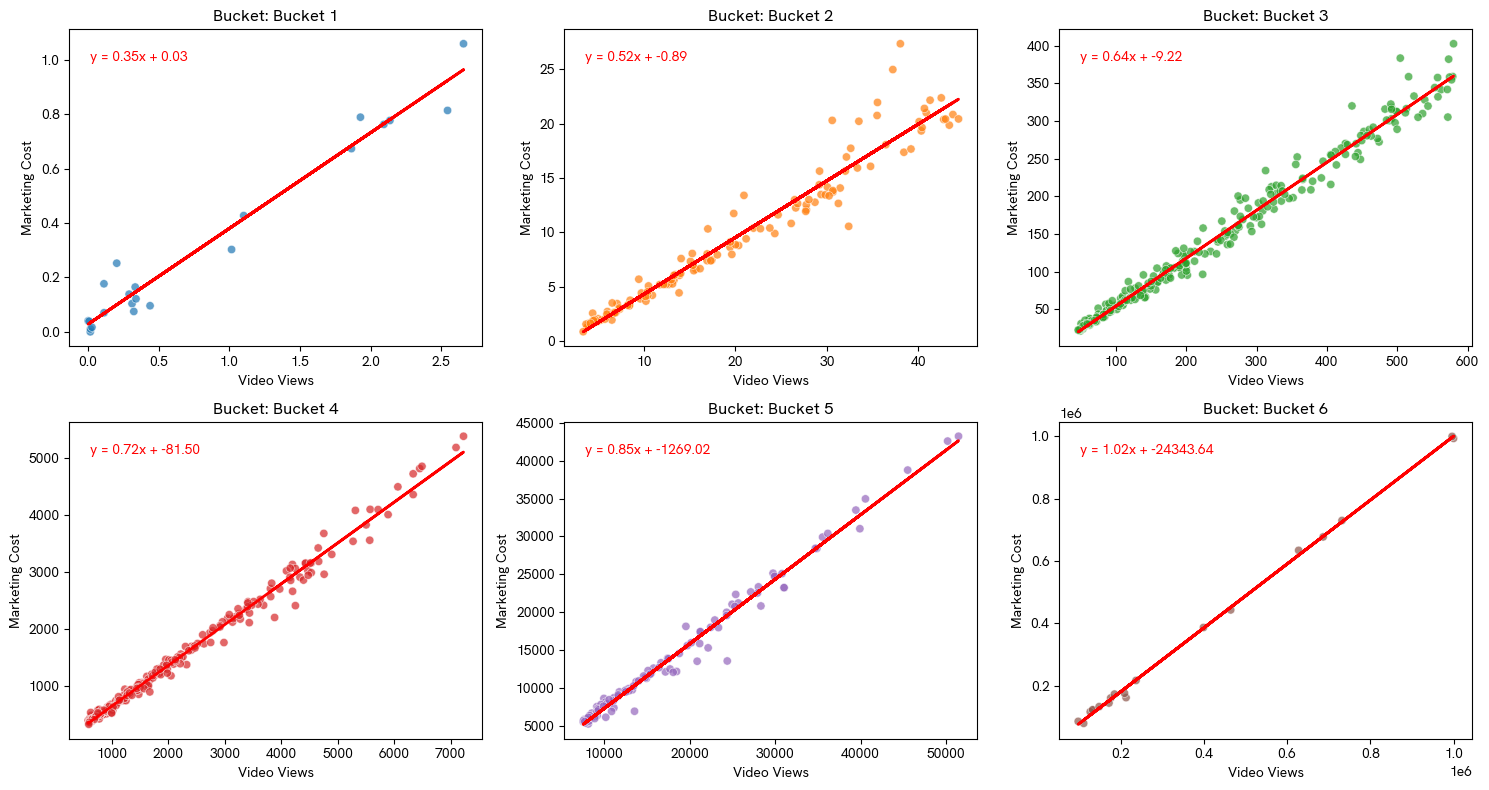

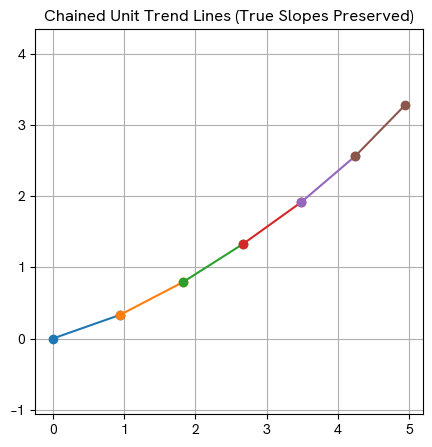

In [281]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

buckets = ['Bucket 1', 'Bucket 2', 'Bucket 3', 'Bucket 4', 'Bucket 5', 'Bucket 6']

# Part 1: Separate scatter plots with trend lines and equations
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

slopes = []
intercepts = []

for i, bucket in enumerate(buckets):
    subset = bucket_analysis[bucket_analysis["Log Video Views Bucket"] == bucket]
    
    # Scatter plot
    sns.scatterplot(
        data=subset,
        x="Video Views",
        y="Marketing Cost",
        hue="Log Video Views Bucket",
        alpha=0.7,
        ax=axes[i],
        legend=False
    )
    
    # Fit linear regression for the bucket
    x = subset["Video Views"].values
    y = subset["Marketing Cost"].values
    if len(x) > 1:  # Avoid fitting if only one point
        slope, intercept = np.polyfit(x, y, 1)
        slopes.append(slope)
        intercepts.append(intercept)
        
        # Trend line
        axes[i].plot(x, slope * x + intercept, color="red", linewidth=2)
        
        # Equation text
        eq_text = f"y = {slope:.2f}x + {intercept:.2f}"
        axes[i].text(0.05, 0.9, eq_text, transform=axes[i].transAxes, 
                     fontsize=10, color="red", fontweight="bold")
    else:
        # For buckets with one or zero points, store NaN for slope/intercept
        slopes.append(np.nan)
        intercepts.append(np.nan)

    axes[i].set_title(f"Bucket: {bucket}")
    axes[i].set_xlabel("Video Views")
    axes[i].set_ylabel("Marketing Cost")

plt.tight_layout()
plt.show()

# Part 2: Chained unit trend lines plot

# Convert slopes to unit vectors (skip NaNs)
directions = []
valid_buckets = []
valid_slopes = []
valid_intercepts = []

for slope, intercept, bucket in zip(slopes, intercepts, buckets):
    if not np.isnan(slope):
        vec = np.array([1, slope])
        vec = vec / np.linalg.norm(vec)
        directions.append(vec)
        valid_buckets.append(bucket)
        valid_slopes.append(slope)
        valid_intercepts.append(intercept)

# Chain them end-to-end
points = [(0, 0)]
for vec in directions:
    last_point = np.array(points[-1])
    new_point = last_point + vec
    points.append(tuple(new_point))

# Plot chained unit lines
points = np.array(points)
plt.figure(figsize=(5, 5))
for i, bucket in enumerate(valid_buckets):
    plt.plot(points[i:i+2, 0], points[i:i+2, 1], marker="o",
             label=f"{bucket} | y={valid_slopes[i]:.2f}x + {valid_intercepts[i]:.2f}")

plt.axis("equal")
plt.title("Chained Unit Trend Lines (True Slopes Preserved)")
plt.grid(True)
plt.show()


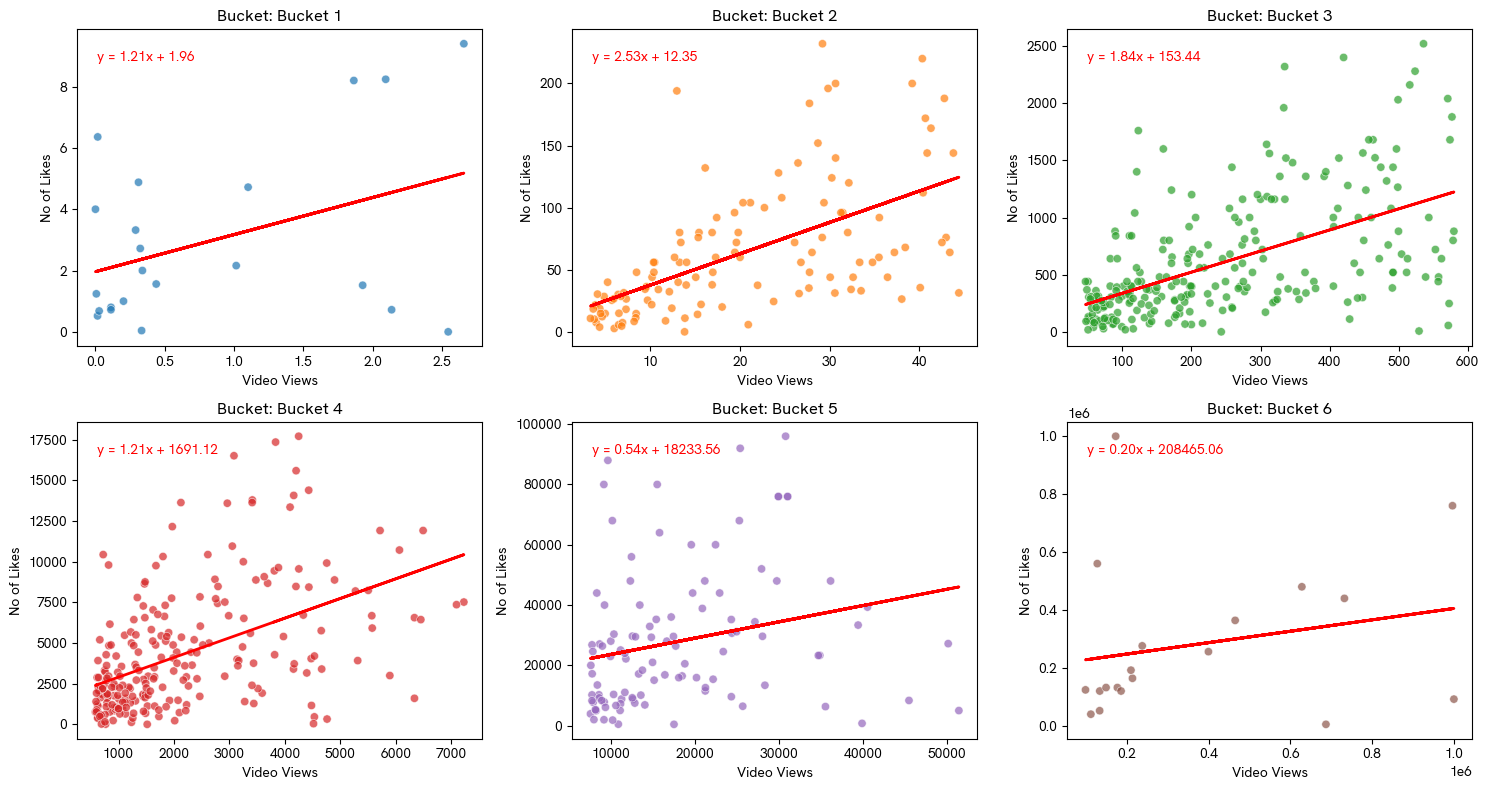

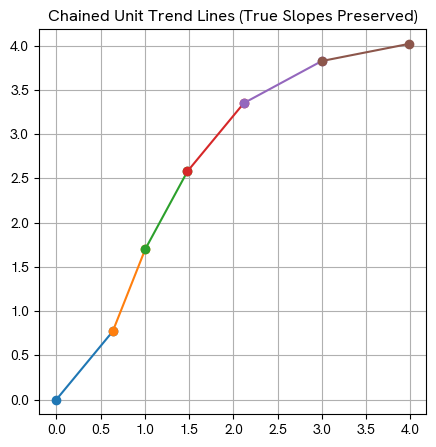

In [282]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

buckets = ['Bucket 1', 'Bucket 2', 'Bucket 3', 'Bucket 4', 'Bucket 5', 'Bucket 6']

# Part 1: Separate scatter plots with trend lines and equations
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

slopes = []
intercepts = []

for i, bucket in enumerate(buckets):
    subset = bucket_analysis[bucket_analysis["Log Video Views Bucket"] == bucket]
    
    # Scatter plot
    sns.scatterplot(
        data=subset,
        x="Video Views",
        y="No of Likes",
        hue="Log Video Views Bucket",
        alpha=0.7,
        ax=axes[i],
        legend=False
    )
    
    # Fit linear regression for the bucket
    x = subset["Video Views"].values
    y = subset["No of Likes"].values
    if len(x) > 1:  # Avoid fitting if only one point
        slope, intercept = np.polyfit(x, y, 1)
        slopes.append(slope)
        intercepts.append(intercept)
        
        # Trend line
        axes[i].plot(x, slope * x + intercept, color="red", linewidth=2)
        
        # Equation text
        eq_text = f"y = {slope:.2f}x + {intercept:.2f}"
        axes[i].text(0.05, 0.9, eq_text, transform=axes[i].transAxes, 
                     fontsize=10, color="red", fontweight="bold")
    else:
        # For buckets with one or zero points, store NaN for slope/intercept
        slopes.append(np.nan)
        intercepts.append(np.nan)

    axes[i].set_title(f"Bucket: {bucket}")
    axes[i].set_xlabel("Video Views")
    axes[i].set_ylabel("No of Likes")

plt.tight_layout()
plt.show()

# Part 2: Chained unit trend lines plot

# Convert slopes to unit vectors (skip NaNs)
directions = []
valid_buckets = []
valid_slopes = []
valid_intercepts = []

for slope, intercept, bucket in zip(slopes, intercepts, buckets):
    if not np.isnan(slope):
        vec = np.array([1, slope])
        vec = vec / np.linalg.norm(vec)
        directions.append(vec)
        valid_buckets.append(bucket)
        valid_slopes.append(slope)
        valid_intercepts.append(intercept)

# Chain them end-to-end
points = [(0, 0)]
for vec in directions:
    last_point = np.array(points[-1])
    new_point = last_point + vec
    points.append(tuple(new_point))

# Plot chained unit lines
points = np.array(points)
plt.figure(figsize=(5, 5))
for i, bucket in enumerate(valid_buckets):
    plt.plot(points[i:i+2, 0], points[i:i+2, 1], marker="o",
             label=f"{bucket} | y={valid_slopes[i]:.2f}x + {valid_intercepts[i]:.2f}")

plt.axis("equal")
plt.title("Chained Unit Trend Lines (True Slopes Preserved)")
plt.grid(True)
plt.show()


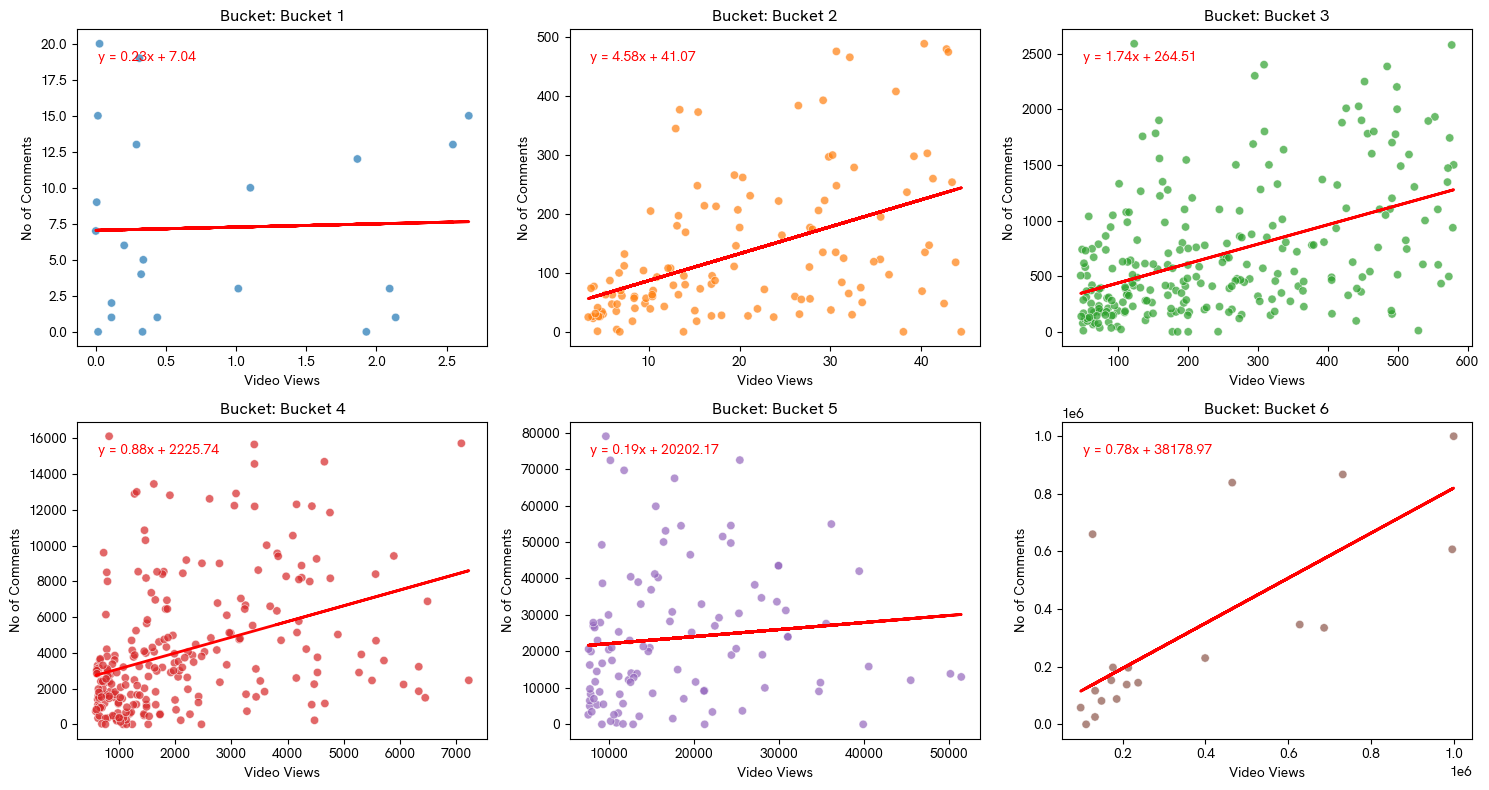

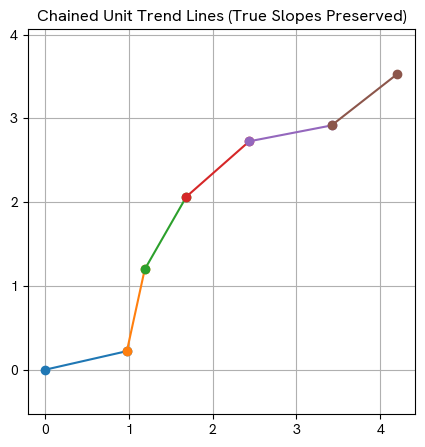

In [283]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

buckets = ['Bucket 1', 'Bucket 2', 'Bucket 3', 'Bucket 4', 'Bucket 5', 'Bucket 6']

# Part 1: Separate scatter plots with trend lines and equations
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

slopes = []
intercepts = []

for i, bucket in enumerate(buckets):
    subset = bucket_analysis[bucket_analysis["Log Video Views Bucket"] == bucket]
    
    # Scatter plot
    sns.scatterplot(
        data=subset,
        x="Video Views",
        y="No of Comments",
        hue="Log Video Views Bucket",
        alpha=0.7,
        ax=axes[i],
        legend=False
    )
    
    # Fit linear regression for the bucket
    x = subset["Video Views"].values
    y = subset["No of Comments"].values
    if len(x) > 1:  # Avoid fitting if only one point
        slope, intercept = np.polyfit(x, y, 1)
        slopes.append(slope)
        intercepts.append(intercept)
        
        # Trend line
        axes[i].plot(x, slope * x + intercept, color="red", linewidth=2)
        
        # Equation text
        eq_text = f"y = {slope:.2f}x + {intercept:.2f}"
        axes[i].text(0.05, 0.9, eq_text, transform=axes[i].transAxes, 
                     fontsize=10, color="red", fontweight="bold")
    else:
        # For buckets with one or zero points, store NaN for slope/intercept
        slopes.append(np.nan)
        intercepts.append(np.nan)

    axes[i].set_title(f"Bucket: {bucket}")
    axes[i].set_xlabel("Video Views")
    axes[i].set_ylabel("No of Comments")

plt.tight_layout()
plt.show()

# Part 2: Chained unit trend lines plot

# Convert slopes to unit vectors (skip NaNs)
directions = []
valid_buckets = []
valid_slopes = []
valid_intercepts = []

for slope, intercept, bucket in zip(slopes, intercepts, buckets):
    if not np.isnan(slope):
        vec = np.array([1, slope])
        vec = vec / np.linalg.norm(vec)
        directions.append(vec)
        valid_buckets.append(bucket)
        valid_slopes.append(slope)
        valid_intercepts.append(intercept)

# Chain them end-to-end
points = [(0, 0)]
for vec in directions:
    last_point = np.array(points[-1])
    new_point = last_point + vec
    points.append(tuple(new_point))

# Plot chained unit lines
points = np.array(points)
plt.figure(figsize=(5, 5))
for i, bucket in enumerate(valid_buckets):
    plt.plot(points[i:i+2, 0], points[i:i+2, 1], marker="o",
             label=f"{bucket} | y={valid_slopes[i]:.2f}x + {valid_intercepts[i]:.2f}")

plt.axis("equal")
plt.title("Chained Unit Trend Lines (True Slopes Preserved)")
plt.grid(True)
plt.show()


küme 4 etkileşim açısından öğimin düzleşmeyue bşalamdıın son küme olarak en verimli kümelerden biri bu yüzden alışamya aldık açıkcası 5. küme hem verim açısından bizi tam düşürmüyor hem de model eğitimi için eldeki veri dengesini koruyor  4 ve 5. kümeleri seçme sebebimiz buydu

### Feature Creation

#### Like and Comment Score

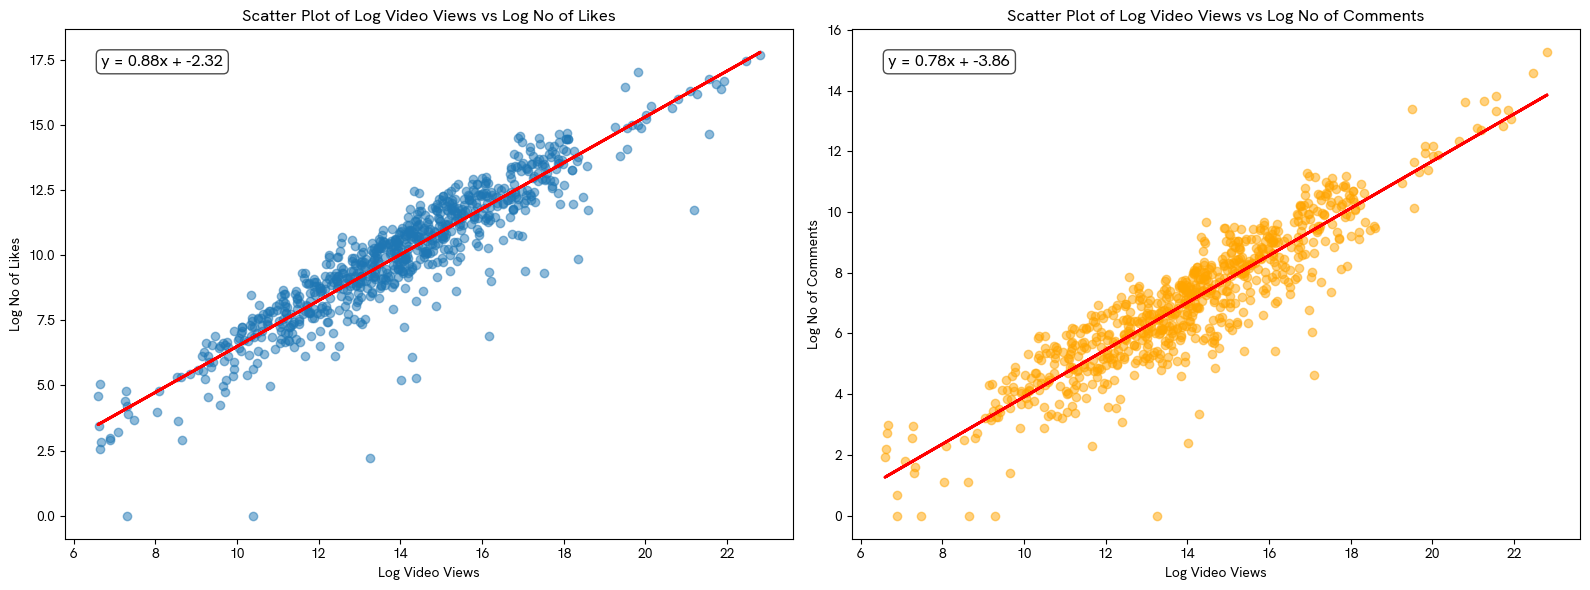

In [284]:
fig, axs = plt.subplots(1, 2, figsize=(16, 6))

# Scatter plot: Log Video Views vs Log No of Likes
axs[0].scatter(df['Log Video Views'], df['Log No of Likes'], alpha=0.5)
axs[0].set_xlabel('Log Video Views')
axs[0].set_ylabel('Log No of Likes')
axs[0].set_title('Scatter Plot of Log Video Views vs Log No of Likes')

# Add trend line
mask0 = df['Log Video Views'].notnull() & df['Log No of Likes'].notnull()
x = df.loc[mask0, 'Log Video Views']
y = df.loc[mask0, 'Log No of Likes']
A = np.vstack([x, np.ones(len(x))]).T
m, c = np.linalg.lstsq(A, y, rcond=None)[0]
axs[0].plot(x, m*x + c, color='red', linewidth=2)
# Show formula on the plot
axs[0].text(
    0.05, 0.95,
    f'y = {m:.2f}x + {c:.2f}',
    transform=axs[0].transAxes,
    fontsize=12,
    verticalalignment='top',
    bbox=dict(boxstyle='round', facecolor='white', alpha=0.7)
)

# Scatter plot: Log Video Views vs Log No of Comments
axs[1].scatter(df['Log Video Views'], df['Log No of Comments'], alpha=0.5, color='orange')
axs[1].set_xlabel('Log Video Views')
axs[1].set_ylabel('Log No of Comments')
axs[1].set_title('Scatter Plot of Log Video Views vs Log No of Comments')

# Add trend line
mask1 = df['Log Video Views'].notnull() & df['Log No of Comments'].notnull()
x = df.loc[mask1, 'Log Video Views']
y = df.loc[mask1, 'Log No of Comments']
A = np.vstack([x, np.ones(len(x))]).T
m, c = np.linalg.lstsq(A, y, rcond=None)[0]
axs[1].plot(x, m*x + c, color='red', linewidth=2)
# Show formula on the plot
axs[1].text(
    0.05, 0.95,
    f'y = {m:.2f}x + {c:.2f}',
    transform=axs[1].transAxes,
    fontsize=12,
    verticalalignment='top',
    bbox=dict(boxstyle='round', facecolor='white', alpha=0.7)
)


plt.tight_layout()
plt.show()

In [285]:
df['Like Score'] = df['Log No of Likes'] / df['Log Video Views']
df['Comment Score'] = df['Log No of Comments'] / df['Log Video Views']



#### Duration Analysis

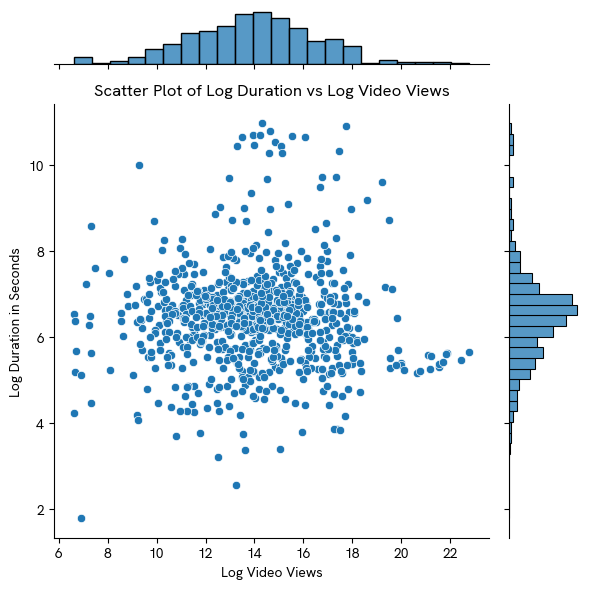

In [286]:
import matplotlib.pyplot as plt

sns.jointplot(data=df, x="Log Video Views", y="Log Duration in Seconds")

plt.ylabel('Log Duration in Seconds')
plt.xlabel('Log Video Views')
plt.title('Scatter Plot of Log Duration vs Log Video Views')



plt.tight_layout()
plt.show()

#### Community Engagement Analysis

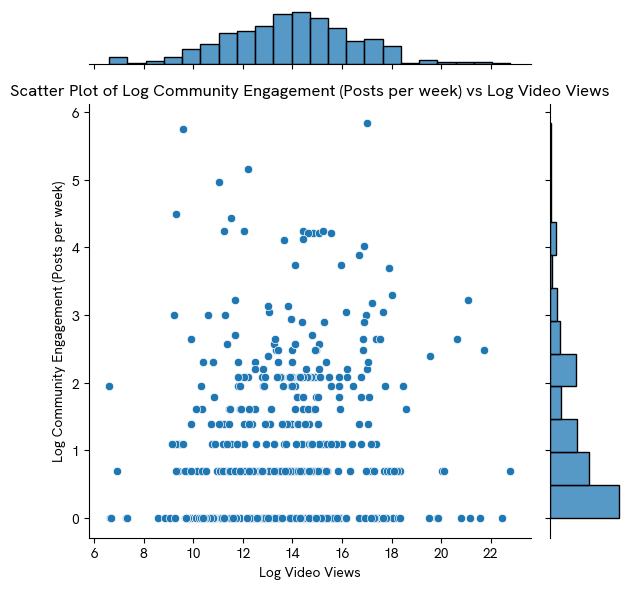

In [287]:
import matplotlib.pyplot as plt

sns.jointplot(data=df, x="Log Video Views", y="Log Community Engagement (Posts per week)")

plt.ylabel('Log Community Engagement (Posts per week)')
plt.xlabel('Log Video Views')
plt.title('Scatter Plot of Log Community Engagement (Posts per week) vs Log Video Views')



plt.tight_layout()
plt.show()

#### Loyalty Score ??????

In [288]:
df.sort_values(by='Date of Video Upload', ascending=True,inplace=True)

In [289]:
df.groupby("Channel URL")["Log Video Views"].apply(lambda x: x.shift().expanding().mean()).tail(10)

Channel URL                                  
https://www.youtube.com/user/natefiggs    593          NaN
https://www.youtube.com/user/pibindia     731          NaN
https://www.youtube.com/user/sonyliv      205          NaN
https://www.youtube.com/user/steviecutts  657          NaN
https://www.youtube.com/variant           242          NaN
illacertus - YouTube                      520          NaN
                                          415    14.264001
                                          167    15.240284
                                          522    14.503257
youtube.com/c/Thequint                    335          NaN
Name: Log Video Views, dtype: float64

In [290]:
df.columns

Index(['Video Views', 'Video Title', 'Channel URL', 'Creator Name',
       'Creator Gender', 'Total Channel Subcribers', 'Total Chanel Views',
       'Duration of Video', 'Duration in Seconds', 'Date of Video Upload',
       'No of Likes', 'Language of the Video', 'Subtitle', 'Video Description',
       'Hashtags', 'No of Comments', 'Date of the Last Comment',
       'Maximum Quality of the Video', 'No of Videos the Channel',
       'No of Playlist', 'Premiered or Not',
       'Community Engagement (Posts per week)', 'DayOfWeek', 'Friday',
       'Monday', 'Saturday', 'Sunday', 'Thursday', 'Tuesday', 'Wednesday',
       'Log Video Views', 'Log Total Channel Subcribers',
       'Log Total Chanel Views', 'Log Duration in Seconds', 'Log No of Likes',
       'Log Hashtags', 'Log No of Comments',
       'Log Maximum Quality of the Video', 'Log No of Videos the Channel',
       'Log No of Playlist', 'Log Premiered or Not',
       'Log Community Engagement (Posts per week)', 'CPM', 'Sub Bonus

In [291]:
df["Mean Log Views Until Then"] = (
    df.groupby("Channel URL")["Log Video Views"].transform(lambda x: x.expanding().mean())
)

# 5. İlgili 3 sütunu seç

df[["Channel URL","Date of Video Upload" ,"Log Video Views", "Mean Log Views Until Then", "Log Total Channel Subcribers"]].sort_values(by=["Channel URL", "Date of Video Upload"])

,Channel URL,Date of Video Upload,Log Video Views,Mean Log Views Until Then,Log Total Channel Subcribers
709,(1) Dr. Vivek Bindra: Motivational Speaker - Y...,2019-04-26,16.877023,16.877023,16.801192
760,(14) Mr.Heang Update - YouTube,2022-05-05,19.657930,19.657930,15.782623
716,(14) RC MEDIA WORLD - YouTube,2020-11-01,18.208104,18.208104,14.719729
743,(14) TheRichest - YouTube,2015-10-29,18.474132,18.474132,16.530205
723,(16) 5-Minute DECOR - YouTube,2020-03-31,18.571896,18.571896,15.989125
...,...,...,...,...,...
520,illacertus - YouTube,2016-10-03,14.264001,14.264001,13.030248
415,illacertus - YouTube,2017-02-03,16.216568,15.240284,13.030248
167,illacertus - YouTube,2017-04-29,13.029201,14.503257,13.030248
522,illacertus - YouTube,2019-01-02,14.682783,14.548138,13.030248


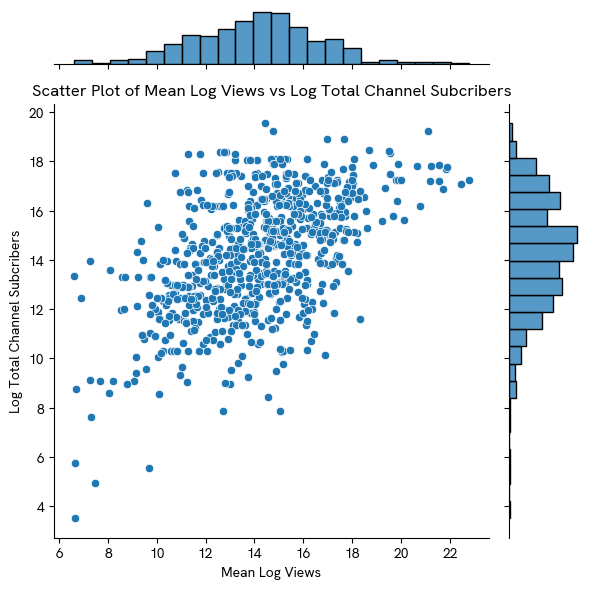

In [292]:
sns.jointplot(data=df, x="Mean Log Views Until Then", y="Log Total Channel Subcribers")

plt.ylabel('Log Total Channel Subcribers')
plt.xlabel('Mean Log Views')
plt.title('Scatter Plot of Mean Log Views vs Log Total Channel Subcribers')



plt.tight_layout()
plt.show()

<Axes: xlabel='Loyalty Score', ylabel='Count'>

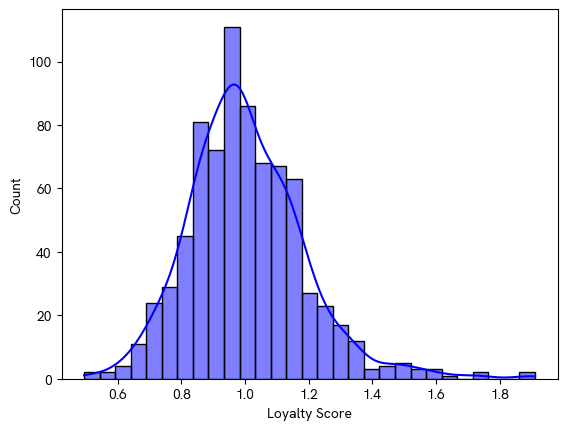

In [293]:
df["Loyalty Score"] =  df["Mean Log Views Until Then"] / df["Log Total Channel Subcribers"] 

sns.histplot(data=df, x="Loyalty Score", kde=True, color='blue')

#### Atractness Score

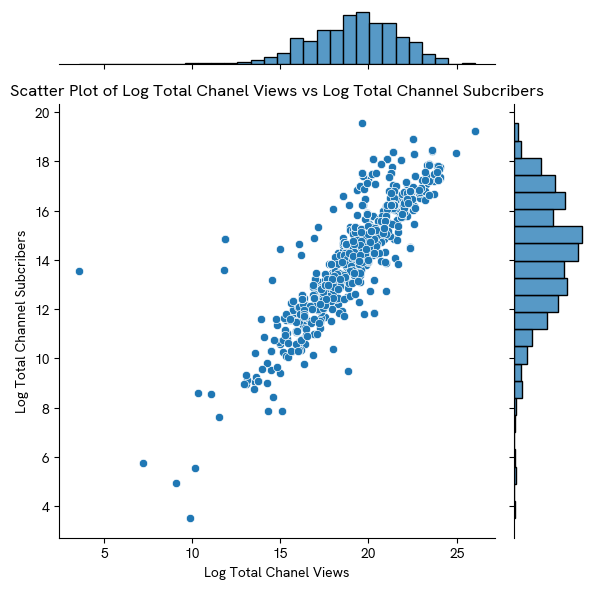

In [294]:
sns.jointplot(data=df, x="Log Total Chanel Views", y="Log Total Channel Subcribers")

plt.xlabel('Log Total Chanel Views')
plt.ylabel('Log Total Channel Subcribers')
plt.title('Scatter Plot of Log Total Chanel Views vs Log Total Channel Subcribers')



plt.tight_layout()
plt.show()

<Axes: xlabel='Atractness Score', ylabel='Count'>

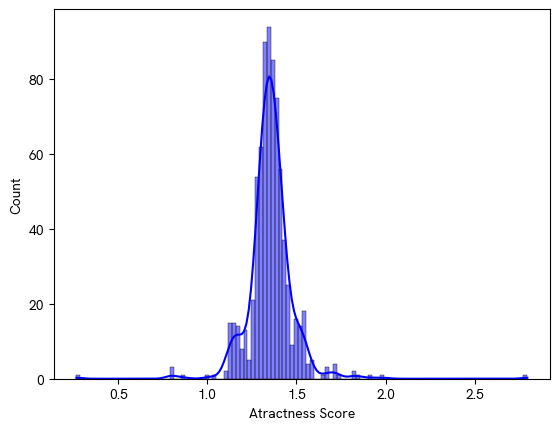

In [295]:
df["Atractness Score"] =  df["Log Total Chanel Views"] / df["Log Total Channel Subcribers"] 

sns.histplot(data=df, x="Atractness Score", kde=True, color='blue')

#### Efficiency Score

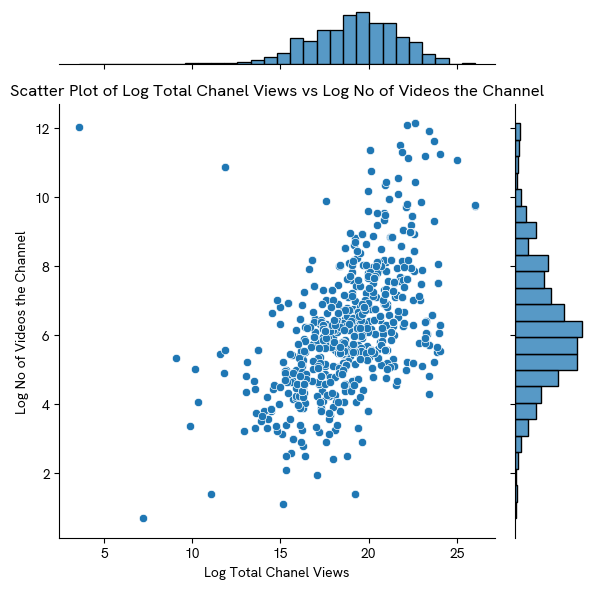

In [296]:
sns.jointplot(data=df, x="Log Total Chanel Views", y="Log No of Videos the Channel")

plt.xlabel('Log Total Chanel Views')
plt.ylabel('Log No of Videos the Channel')
plt.title('Scatter Plot of Log Total Chanel Views vs Log No of Videos the Channel')

plt.tight_layout()
plt.show()

<Axes: xlabel='Efficiency Score', ylabel='Count'>

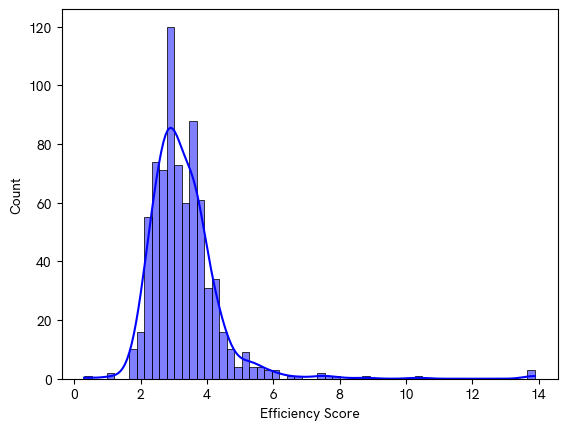

In [297]:
df["Efficiency Score"] =  df["Log Total Chanel Views"] / df["Log No of Videos the Channel"] 

sns.histplot(data=df, x="Efficiency Score", kde=True, color='blue')

In [298]:
df[["Creator Name","Efficiency Score"]].sort_values(by="Efficiency Score", ascending=False).head(10)

,Creator Name,Efficiency Score
673,Anubhav Singh Bassi,13.886011
740,Anubhav Singh Bassi,13.885159
493,Blockshelf,13.784393
13,Udyansh Society,10.369597
611,Court Room,8.764751
32,America Chowrasta FinTech,7.965034
657,Steve Cutts,7.554919
411,Varun Grover,7.493355
88,Rob Hamilton,7.352156
701,Abhishek Upmanyu,6.785325


#### Sub Per Video

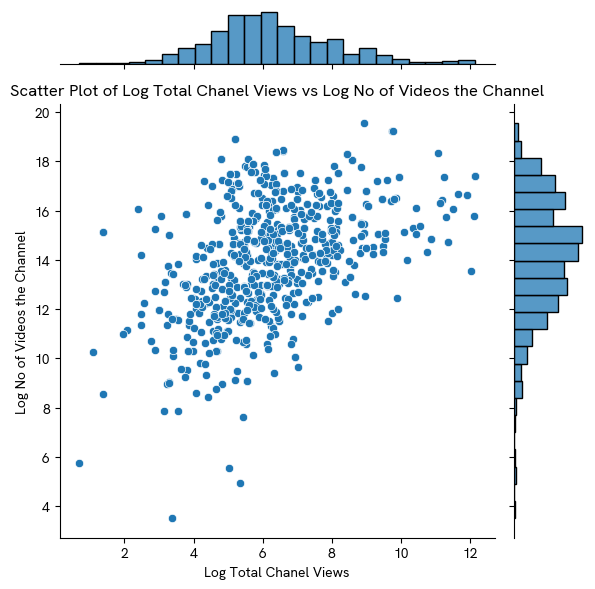

In [299]:
sns.jointplot(data=df, x="Log No of Videos the Channel", y="Log Total Channel Subcribers")

plt.xlabel('Log Total Chanel Views')
plt.ylabel('Log No of Videos the Channel')
plt.title('Scatter Plot of Log Total Chanel Views vs Log No of Videos the Channel')

plt.tight_layout()
plt.show()

<Axes: xlabel='Sub Per Video', ylabel='Count'>

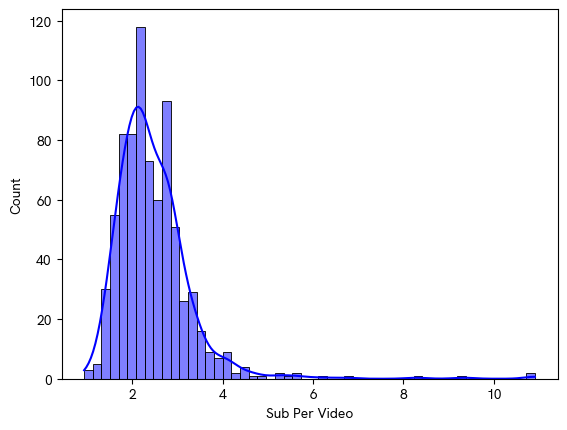

In [300]:
df["Sub Per Video"] =  df["Log Total Channel Subcribers"] / df["Log No of Videos the Channel"] 

sns.histplot(data=df, x="Sub Per Video", kde=True, color='blue')

In [301]:
df[["Creator Name","Sub Per Video"]].sort_values(by="Sub Per Video", ascending=False).head(10)

,Creator Name,Sub Per Video
673,Anubhav Singh Bassi,10.911494
740,Anubhav Singh Bassi,10.911494
493,Blockshelf,9.340112
13,Udyansh Society,8.285402
411,Varun Grover,6.700816
32,America Chowrasta FinTech,6.174917
657,Steve Cutts,5.717540
611,Court Room,5.638308
88,Rob Hamilton,5.363646
701,Abhishek Upmanyu,5.270529


## Exporting the Data

In [302]:
df.columns

Index(['Video Views', 'Video Title', 'Channel URL', 'Creator Name',
       'Creator Gender', 'Total Channel Subcribers', 'Total Chanel Views',
       'Duration of Video', 'Duration in Seconds', 'Date of Video Upload',
       'No of Likes', 'Language of the Video', 'Subtitle', 'Video Description',
       'Hashtags', 'No of Comments', 'Date of the Last Comment',
       'Maximum Quality of the Video', 'No of Videos the Channel',
       'No of Playlist', 'Premiered or Not',
       'Community Engagement (Posts per week)', 'DayOfWeek', 'Friday',
       'Monday', 'Saturday', 'Sunday', 'Thursday', 'Tuesday', 'Wednesday',
       'Log Video Views', 'Log Total Channel Subcribers',
       'Log Total Chanel Views', 'Log Duration in Seconds', 'Log No of Likes',
       'Log Hashtags', 'Log No of Comments',
       'Log Maximum Quality of the Video', 'Log No of Videos the Channel',
       'Log No of Playlist', 'Log Premiered or Not',
       'Log Community Engagement (Posts per week)', 'CPM', 'Sub Bonus

In [303]:
df.describe()

,Video Views,Total Channel Subcribers,Total Chanel Views,Duration in Seconds,Date of Video Upload,No of Likes,Hashtags,No of Comments,Maximum Quality of the Video,No of Videos the Channel,...,Sub Bonus,CPM_Enhanced,Marketing Cost,Like Score,Comment Score,Mean Log Views Until Then,Loyalty Score,Atractness Score,Efficiency Score,Sub Per Video
count,7.680000e+02,7.670000e+02,7.600000e+02,768.000000,768,7.680000e+02,768.000000,7.680000e+02,768.000000,768.000000,...,768.000000,768.000000,7.680000e+02,766.000000,747.000000,768.000000,767.000000,759.000000,760.000000,767.000000
mean,5.778499e+07,1.004377e+07,2.339054e+09,1802.380208,2021-01-07 12:43:07.500000,4.837323e+05,1.033854,2.300749e+04,1234.062500,4758.441406,...,1.364202,5.621721,5.130837e+08,0.708845,0.490284,14.108692,1.003332,1.354149,3.306095,2.462044
min,7.310000e+02,3.400000e+01,3.600000e+01,6.000000,2006-10-10 00:00:00,0.000000e+00,0.000000,0.000000e+00,240.000000,2.000000,...,0.000000,1.132045,8.671465e+02,0.000000,0.000000,6.594413,0.494189,0.264234,0.298136,0.927999
25%,2.015388e+05,3.295000e+05,3.712224e+07,322.500000,2020-06-04 12:00:00,4.675000e+03,0.000000,2.212500e+02,1080.000000,163.000000,...,1.170630,4.826089,1.022486e+06,0.674749,0.439250,12.390737,0.881453,1.303020,2.659281,1.946772
50%,1.246764e+06,1.960000e+06,2.475236e+08,652.000000,2022-02-10 00:00:00,2.500000e+04,0.000000,9.785000e+02,1080.000000,445.000000,...,1.395978,5.721518,6.920791e+06,0.724696,0.505914,14.179383,0.985416,1.350940,3.112456,2.296218
75%,6.879928e+06,8.685000e+06,1.242398e+09,1029.500000,2022-09-09 00:00:00,1.305000e+05,1.000000,4.358750e+03,1080.000000,1536.500000,...,1.588081,6.370221,4.396464e+07,0.763358,0.555149,15.785223,1.109776,1.403070,3.693177,2.826211
max,7.990990e+09,3.052000e+08,2.022970e+11,57600.000000,2022-12-09 00:00:00,4.900000e+07,28.000000,4.238809e+06,2160.000000,186562.000000,...,2.000000,9.747586,7.789286e+10,0.870181,0.687105,22.801580,1.910903,2.796559,13.886011,10.911494
std,4.323221e+08,2.399583e+07,1.137139e+10,5861.884619,NaN,2.865703e+06,1.870348,1.872721e+05,423.480526,20231.021769,...,0.292087,1.267026,4.102458e+09,0.087810,0.094988,2.641687,0.183150,0.131476,1.137429,0.889611


In [304]:
df.to_csv("youtube_influencers_data_cleaned.csv", index=False)